📊 DATASET
    Study_Hours  Attendance
0           1.0          50
1           1.5          52
2           2.0          55
3           2.5          58
4           3.0          60
5           6.0          80
6           6.5          82
7           7.0          85
8           7.5          87
9           8.0          90
10          4.5          68
11          5.0          70
12          5.5          73
13         10.0          40

🔵 DBSCAN CLUSTERING COMPLETED!

📌 CLUSTERED DATA
    Study_Hours  Attendance  Cluster
0           1.0          50        0
1           1.5          52        0
2           2.0          55        0
3           2.5          58        0
4           3.0          60        0
5           6.0          80        0
6           6.5          82        0
7           7.0          85        0
8           7.5          87        0
9           8.0          90        0
10          4.5          68        0
11          5.0          70        0
12          5.5          73        0
13

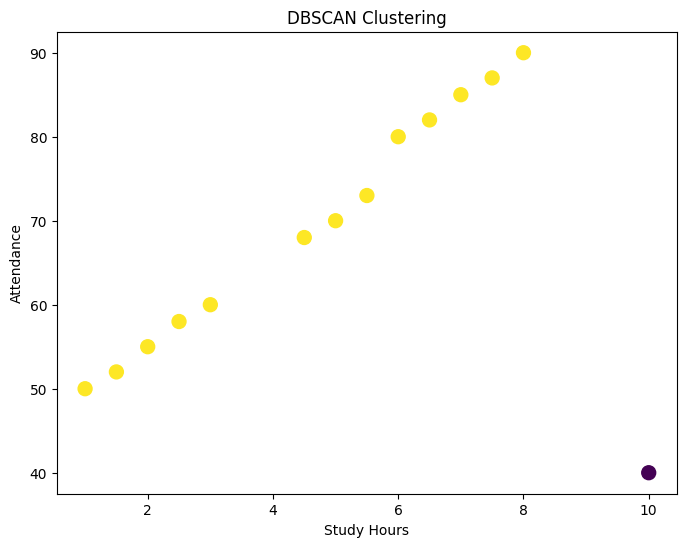


🚨 NOISE / OUTLIERS
    Study_Hours  Attendance  Cluster
13         10.0          40       -1


In [2]:
# =====================================================
# 🔵 Day 24 - DBSCAN Clustering
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Create Dataset
data = {
    "Study_Hours": [
        1, 1.5, 2, 2.5, 3,
        6, 6.5, 7, 7.5, 8,
        4.5, 5, 5.5,
        10
    ],
    "Attendance": [
        50, 52, 55, 58, 60,
        80, 82, 85, 87, 90,
        68, 70, 73,
        40
    ]
}

df = pd.DataFrame(data)

print("📊 DATASET")
print(df)

# 2. Select Features
X = df[["Study_Hours", "Attendance"]]

# 3. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Create DBSCAN Model
model = DBSCAN(
    eps=0.8,
    min_samples=2
)

# 5. Perform Clustering
df["Cluster"] = model.fit_predict(X_scaled)

print("\n🔵 DBSCAN CLUSTERING COMPLETED!")

print("\n📌 CLUSTERED DATA")
print(df)

# 6. Display Unique Clusters
print("\n🔢 UNIQUE CLUSTERS")
print(df["Cluster"].unique())

# -1 represents Noise / Outlier
noise_count = sum(df["Cluster"] == -1)

print("\n🚨 NUMBER OF NOISE POINTS:", noise_count)

# 7. Visualize Clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Study_Hours"],
    df["Attendance"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("DBSCAN Clustering")
plt.show()

# 8. Display Noise Points
print("\n🚨 NOISE / OUTLIERS")
print(df[df["Cluster"] == -1])